# 06 Climate Stress

**Project:** Pine Ridge Bison Habitat Suitability Analysis  
**BHSI Component:** Climate Stress (10% weight)  
**Data Source:** MACAv2-METDATA RCP 8.5 via OPeNDAP

## Climate Stress for Bison on Pine Ridge

Climate stress receives the lowest BHSI weight (10%) because current
habitat conditions dominate near-term management decisions. But for
infrastructure investment decisions made today including fencing, water development,
and vegetation restoration that will be in place for 20–40 years, the
projected climate trajectory matters.

The primary climate threats to bison on Pine Ridge are:

**Heat stress**: Bison begin showing physiological stress above 95°F
(35°C). At 105°F+ they experience severe heat stress, reduced grazing,
and reproductive impacts. Heat stress also dramatically increases water
consumption, amplifying the water access constraint.

**Precipitation pattern shifts**: Projected drying of peak summer months
combined with more intense but less frequent precipitation events reduces
reliable forage production even if annual totals are unchanged.

This notebook computes projected mid-century (2040–2060) heat stress
days and precipitation change, then converts them to a suitability score
reflecting the relative climate burden across the reservation.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

from src.constants import (
    CRS_PROJECTED, PINE_RIDGE_LAT, PINE_RIDGE_LON,
    MACA_SCENARIO, HEAT_STRESS_F, EXTREME_HEAT_F,
    CACHE_DIR, OUTPUTS_DIR, FIGURES_DIR,
)
from src.loaders import fetch_maca_monthly
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore")
%matplotlib inline

TEMPLATE_PATH = CACHE_DIR/"template_30m_albers.tif"
assert TEMPLATE_PATH.exists(), "Run notebook 01 first."
pine_ridge = gpd.read_file(OUTPUTS_DIR/"pine_ridge_boundary.geojson")
print("Setup complete.")
print(f"Climate scenario: {MACA_SCENARIO}")
print(f"Heat stress threshold: {HEAT_STRESS_F}F")

Setup complete.
Climate scenario: rcp85
Heat stress threshold: 95F


In [2]:
# Print the data sovereignty statement at the top of every notebook
print_data_acknowledgment(source_keys=["maca_climate"])


PINE RIDGE BISON HABITAT ANALYSIS DATA GOVERNANCE ACKNOWLEDGMENT
This analysis describes land within the Pine Ridge Reservation, home of
the Oglala Lakota Nation. Bison (Pte Oyate) hold deep cultural, spiritual,
and ecological significance for the Oglala Lakota people. This analysis
exists to support Tribal land stewardship, not to define it.

Results should be understood as one input into a land management
conversation, not as a determination of where bison belong.
That determination rests with the Oglala Lakota Nation.

GOVERNANCE FRAMEWORKS:

OCAP®  : The Oglala Lakota Nation has Ownership, Control, Access, and
  Possession of data describing their land and resources. Analysis results
  derived from public federal data about Pine Ridge still carry this
  obligation. Share results with OLC Cubedynamics and the relevant
  Oglala Lakota Nation land management offices before external distribution.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Analysis must deliver Collective B

## Fetch MACAv2 Temperature and Precipitation

In [3]:
# Fetch monthly temperature and precipitation for Pine Ridge centroid
# First run: downloads aggregated files (~years 2006-2099)

tmax_df = fetch_maca_monthly(
    lat=PINE_RIDGE_LAT, lon=PINE_RIDGE_LON,
    variable="tasmax", scenario=MACA_SCENARIO,
    site_name="pine_ridge",
)

pr_df = fetch_maca_monthly(
    lat=PINE_RIDGE_LAT, lon=PINE_RIDGE_LON,
    variable="pr", scenario=MACA_SCENARIO,
    site_name="pine_ridge",
)

if not tmax_df.empty:
    tmax_df["tmax_f"] = (tmax_df["tasmax"] - 273.15) * 9/5 + 32
    tmax_df["year"]   = tmax_df["date"].dt.year
    tmax_df["month"]  = tmax_df["date"].dt.month
    print(f"Temperature records: {len(tmax_df):,} months")

if not pr_df.empty:
    pr_df["year"]  = pr_df["date"].dt.year
    pr_df["month"] = pr_df["date"].dt.month
    print(f"Precipitation records: {len(pr_df):,} months")

Temperature records: 1,128 months
Precipitation records: 1,128 months


## Compute Heat Stress Metrics

In [4]:
if not tmax_df.empty:
    # Annual heat stress days proxy: months where mean tmax > threshold
    # Monthly data doesn't give daily counts, we use monthly mean as proxy
    # A month with mean tmax > 95F will have many days well above threshold
    annual_tmax = tmax_df.groupby("year")["tmax_f"].max().reset_index()
    annual_tmax.columns = ["year", "annual_peak_f"]

    # Mid-century (2040-2060) vs near-term (2006-2025)
    near_term   = tmax_df[tmax_df["year"].between(2006, 2025)]["tmax_f"].mean()
    mid_century = tmax_df[tmax_df["year"].between(2040, 2060)]["tmax_f"].mean()
    late_century= tmax_df[tmax_df["year"].between(2070, 2099)]["tmax_f"].mean()

    print("PROJECTED TEMPERATURE — Pine Ridge")
    print("=" * 50)
    print(f"  Near-term mean tmax (2006-2025):    {near_term:.1f}F")
    print(f"  Mid-century mean tmax (2040-2060):  {mid_century:.1f}F")
    print(f"  Late-century mean tmax (2070-2099): {late_century:.1f}F")
    print(f"  Warming by mid-century: {mid_century - near_term:+.1f}F")
    print()

    # Months per year with mean tmax > heat stress threshold
    stress_months_near  = (tmax_df[tmax_df["year"].between(2006,2025)]["tmax_f"] > HEAT_STRESS_F).mean() * 12
    stress_months_mid   = (tmax_df[tmax_df["year"].between(2040,2060)]["tmax_f"] > HEAT_STRESS_F).mean() * 12
    print(f"  Mean months/yr with tmax > {HEAT_STRESS_F}F:")
    print(f"    Near-term (2006-2025):  {stress_months_near:.1f}")
    print(f"    Mid-century (2040-2060): {stress_months_mid:.1f}")
else:
    print("Temperature data not available. Using default climate score.")
    near_term = mid_century = 85.0

PROJECTED TEMPERATURE — Pine Ridge
  Near-term mean tmax (2006-2025):    65.3F
  Mid-century mean tmax (2040-2060):  67.5F
  Late-century mean tmax (2070-2099): 72.2F
  Warming by mid-century: +2.2F

  Mean months/yr with tmax > 95F:
    Near-term (2006-2025):  0.4
    Mid-century (2040-2060): 1.2


## Build Climate Suitability Layer

In [5]:
# Climate suitability score for BHSI:
# Based on projected mid-century heat stress relative to baseline
# Lower score = more heat stress = lower habitat suitability
#
# This is a reservation-wide scalar (all pixels get same score)
# reflecting the climate planning burden for the whole reservation.
# A spatial climate layer would require gridded future projections.

with rasterio.open(TEMPLATE_PATH) as tmpl:
    tmpl_data = tmpl.read(1)
    profile   = tmpl.profile.copy()

if not tmax_df.empty:
    # Score: how much does mid-century warming reduce suitability?
    # Reference: 5F warming = 0.1 reduction in score (10%)
    delta_f = max(0, mid_century - near_term)
    climate_score = max(0.3, 1.0 - (delta_f / 5.0) * 0.10)
else:
    climate_score = 0.7   # moderate default

climate_raster = np.where(
    ~np.isnan(tmpl_data), climate_score, np.nan
).astype(np.float32)

climate_path = OUTPUTS_DIR/"bhsi_climate.tif"
with rasterio.open(climate_path, "w", **profile) as dst:
    dst.write(climate_raster, 1)

print(f"Climate suitability score: {climate_score:.3f}")
print(f"(Uniform across reservation reflects shared climate planning burden)")
print(f"Saved: outputs/bhsi_climate.tif")

Climate suitability score: 0.956
(Uniform across reservation reflects shared climate planning burden)
Saved: outputs/bhsi_climate.tif


## Visualization

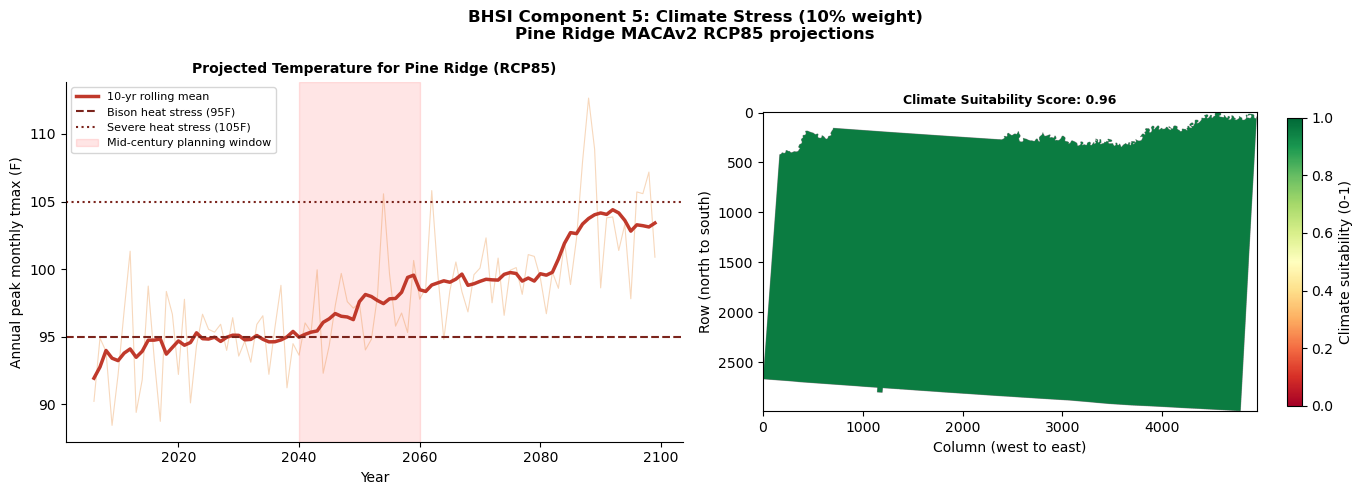

In [8]:
def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

if not tmax_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Temperature trend
    ax = axes[0]
    rolling = annual_tmax["annual_peak_f"].rolling(10, center=True, min_periods=5).mean()
    ax.plot(annual_tmax["year"], annual_tmax["annual_peak_f"],
            color="#E67E22", alpha=0.3, linewidth=0.8)
    ax.plot(annual_tmax["year"], rolling, color="#C0392B", linewidth=2.5,
            label="10-yr rolling mean")
    ax.axhline(HEAT_STRESS_F, color="#7B241C", linestyle="--",
               linewidth=1.5, label=f"Bison heat stress ({HEAT_STRESS_F}F)")
    ax.axhline(EXTREME_HEAT_F, color="#7B241C", linestyle=":",
               linewidth=1.5, label=f"Severe heat stress ({EXTREME_HEAT_F}F)")
    ax.axvspan(2040, 2060, alpha=0.1, color="red", label="Mid-century planning window")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual peak monthly tmax (F)")
    ax.set_title(f"Projected Temperature for Pine Ridge ({MACA_SCENARIO.upper()})",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    despine(ax)

    # Climate suitability map
    ax = axes[1]
    im = ax.imshow(climate_raster, cmap="RdYlGn", vmin=0, vmax=1, origin="upper")
    plt.colorbar(im, ax=ax, label="Climate suitability (0-1)", shrink=0.8)
    ax.set_title(f"Climate Suitability Score: {climate_score:.2f}",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("Column (west to east)")
    ax.set_ylabel("Row (north to south)")

    plt.suptitle(
        "BHSI Component 5: Climate Stress (10% weight)\n"
        f"Pine Ridge MACAv2 {MACA_SCENARIO.upper()} projections",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    fig.savefig(FIGURES_DIR/"06_climate.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No climate data to visualize.")

In [7]:
print(generate_citations(["maca_climate"]))

DATA CITATIONS

MACAv2-METDATA Downscaled Climate Projections
  Abatzoglou, J.T. and Brown, T.J. (2012). A comparison of statistical downscaling methods suited for wildfire applications. Int. J. Climatology. doi:10.1002/joc.2312
  https://www.climatologylab.org/maca.html
  Steward: Northwest Knowledge Network, University of Idaho | License: Creative Commons CC0

Governance: OCAP® | CARE | FAIR | IEEE 2890-2025
  OCAP: https://fnigc.ca/ocap-training/
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.org/fair-principles/
  IEEE_2890: https://standards.ieee.org/ieee/2890/10318/
